# 🧀 Canadian Cheese Directory — Data Analysis
### CSF Data Analyst Internship Assessment 2025
**Mariyam Sohail | Ontario Tech University | sohailmariam135@gmail.com**

---

This notebook analyzes the **Canadian Cheese Directory** cross-referenced with **historical provincial temperature data** (1990–2017) to explore whether climate conditions crelate with the type, style, and characteristics of cheese produced across Canada's provinces.

**Pipeline overview:**
1. Data ingestion & inspection  
2. Cleaning & normalization  
3. Feature engineering  
4. Merging datasets  
5. Analysis & inference  
6. Visualizations  
7. Discussion & conclusions


## 1. Imports & Configuration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

COLD_COLOR   = '#4a90d9'
WARM_COLOR   = '#e07b39'
ACCENT_COLOR = '#2ecc71'
BG_COLOR     = '#f8f8f5'

print("Librariees loaded ")


Librariees loaded 


## 2. Data Ingestion

In [14]:
# ── Load raw files ──────────────────────────────────────────────────────────
cheese_raw = pd.read_csv('cheese_data.csv')
temp_raw   = pd.read_csv('Canada_Temperature_Data.csv')

print(f"Cheese dataset  : {cheese_raw.shape[0]:,} rows × {cheese_raw.shape[1]} columns")
print(f"Temperature data: {temp_raw.shape[0]:,} rows × {temp_raw.shape[1]} columns")
print()
print("── Cheese columns ──")
print(cheese_raw.dtypes)
print()
print("── Temp columns ──")
print(temp_raw.dtypes)


Cheese dataset  : 1,042 rows × 13 columns
Temperature data: 1,357,283 rows × 7 columns

── Cheese columns ──
CheeseId                  int64
ManufacturerProvCode     object
ManufacturingTypeEn      object
MoisturePercent         float64
FlavourEn                object
CharacteristicsEn        object
Organic                   int64
CategoryTypeEn           object
MilkTypeEn               object
MilkTreatmentTypeEn      object
RindTypeEn               object
CheeseName               object
FatLevel                 object
dtype: object

── Temp columns ──
Year          int64
Month         int64
Stn_Name     object
Prov         object
Tm          float64
S           float64
P            object
dtype: object


## 3. Data Cleaning & Pipeline

The pipeline addresses:
- Missing values in key columns
- Outlier temperatures from historical stations
- Normalization of province codes
- Standardization of categorical labels


In [15]:
#  PIPELINE STAGE 1 — CHEESE CLEANING

cheese = cheese_raw.copy()

print("=== BEFORE CLEANING ===")
print(cheese.isnull().sum()[cheese.isnull().sum() > 0])
print()

# 1a. Drop rows with no province (can't merge without it)
cheese = cheese.dropna(subset=['ManufacturerProvCode'])

# 1b. Fill missing MilkTypeEn with 'Unknown'
cheese['MilkTypeEn'] = cheese['MilkTypeEn'].fillna('Unknown')

# 1c. Fill missing CategoryTypeEn with 'Unknown'
cheese['CategoryTypeEn'] = cheese['CategoryTypeEn'].fillna('Unknown')

# 1d. Fill missing MoisturePercent with median per category
cheese['MoisturePercent'] = cheese.groupby('CategoryTypeEn')['MoisturePercent'] \
                                   .transform(lambda x: x.fillna(x.median()))

# 1e. Normalize province codes to uppercase stripped strings
cheese['Province'] = cheese['ManufacturerProvCode'].str.strip().str.upper()

# 1f. Simplify milk type — combine rare multi-milk combos into 'Mixed'
common_milks = ['Cow', 'Goat', 'Ewe']
cheese['MilkTypeSimple'] = cheese['MilkTypeEn'].apply(
    lambda x: x if x in common_milks else 'Mixed/Other'
)

# 1g. Binary organic flag
cheese['IsOrganic'] = cheese['Organic'].astype(bool)

# 1h. Map fat level to ordinal scale for analysis
fat_order = {'lower fat': 0, 'low fat': 1, 'light': 2, 'regular': 3, 'extra high fat': 4}
cheese['FatOrdinal'] = cheese['FatLevel'].str.strip().str.lower().map(fat_order)

print("=== AFTER CLEANING ===")
print(cheese.isnull().sum()[cheese.isnull().sum() > 0])
print()
print(f"Cheese records ready: {len(cheese):,}")


=== BEFORE CLEANING ===
MoisturePercent         14
FlavourEn              241
CharacteristicsEn      399
CategoryTypeEn          23
MilkTypeEn               1
MilkTreatmentTypeEn     65
RindTypeEn             321
dtype: int64

=== AFTER CLEANING ===
FlavourEn              241
CharacteristicsEn      399
MilkTreatmentTypeEn     65
RindTypeEn             321
FatOrdinal             358
dtype: int64

Cheese records ready: 1,042


In [16]:
#  PIPELINE STAGE 2 — TEMPERATURE CLEANING & AGGREGATION


temp = temp_raw.copy()

# 2a. Filter to modern era (1990–2017) for relevance
temp = temp[temp['Year'] >= 1990]
print(f"Rows after year filter (≥1990): {len(temp):,}")

# 2b. Remove 'XX' province code (unknown/ambiguous)
temp = temp[temp['Prov'] != 'XX']

# 2c. Sanity-check temperature range — remove physically impossible values
#     Valid monthly mean range for Canada: -50°C to +35°C
temp = temp[(temp['Tm'] >= -50) & (temp['Tm'] <= 35)]
print(f"Rows after temperature outlier removal: {len(temp):,}")

# 2d. Normalize province code
temp['Province'] = temp['Prov'].str.strip().str.upper()

# 2e. Aggregate: mean annual temperature per province
prov_temp = (
    temp.groupby('Province')['Tm']
        .agg(AvgTempC='mean', TempStd='std', StationCount='count')
        .round(2)
        .reset_index()
)

# 2f. Classify provinces as Cold / Moderate / Warm using tertiles
boundaries = prov_temp['AvgTempC'].quantile([1/3, 2/3])
def classify_temp(t):
    if t < boundaries.iloc[0]:   return 'Cold'
    elif t < boundaries.iloc[1]: return 'Moderate'
    else:                        return 'Warm'

prov_temp['TempClass'] = prov_temp['AvgTempC'].apply(classify_temp)

print()
print("Provincial temperature summary:")
print(prov_temp.sort_values('AvgTempC').to_string(index=False))


Rows after year filter (≥1990): 392,977
Rows after temperature outlier removal: 392,935

Provincial temperature summary:
Province  AvgTempC  TempStd  StationCount TempClass
      NU    -11.93    14.40          8837      Cold
      NT     -5.18    15.08          7851      Cold
      YT     -2.71    13.19          7793      Cold
      MB      1.94    13.00         25599      Cold
      SK      2.55    12.19         38409  Moderate
      NL      3.82     8.67         20915  Moderate
      QC      4.23    11.26         57136  Moderate
      NB      4.94    10.14          9968  Moderate
      AB      5.19     9.76         61173      Warm
      PE      5.79     9.39          3000      Warm
      ON      6.37    10.60         53231      Warm
      NS      6.73     8.65         12759      Warm
      BC      7.24     7.97         86264      Warm


## 4. Merging Datasets

In [17]:
#  PIPELINE STAGE 3 — MERGEE ON PROVINCE CODE


# Inner join: only keep provinces that exist in both datasets
merged = cheese.merge(prov_temp[['Province', 'AvgTempC', 'TempClass']], 
                      on='Province', how='inner')

print(f"Cheese records before merge : {len(cheese):,}")
print(f"Cheese records after merge  : {len(merged):,}")
print(f"Provinces matched           : {merged['Province'].nunique()}")
print(f"Provinces in cheese not matched: "
      f"{set(cheese['Province']) - set(prov_temp['Province'])}")
print()
print("Records per province:")
print(merged.groupby(['Province', 'TempClass', 'AvgTempC'])
            .size().rename('CheeseCount')
            .reset_index()
            .sort_values('AvgTempC')
            .to_string(index=False))


Cheese records before merge : 1,042
Cheese records after merge  : 1,042
Provinces matched           : 10
Provinces in cheese not matched: set()

Records per province:
Province TempClass  AvgTempC  CheeseCount
      MB      Cold      1.94           11
      SK  Moderate      2.55            1
      NL  Moderate      3.82            2
      QC  Moderate      4.23          796
      NB  Moderate      4.94           27
      AB      Warm      5.19           13
      PE      Warm      5.79            2
      ON      Warm      6.37          115
      NS      Warm      6.73           10
      BC      Warm      7.24           65


## 5. Feature Engineering — Province-Level Aggregates

In [18]:
# Build a province-level summary table for visualization
prov_summary = merged.groupby(['Province', 'AvgTempC', 'TempClass']).agg(
    CheeseCount       = ('CheeseId',       'count'),
    AvgMoisture       = ('MoisturePercent', 'mean'),
    AvgFatOrdinal     = ('FatOrdinal',      'mean'),
    OrganicPct        = ('IsOrganic',       'mean'),
    RawMilkPct        = ('MilkTreatmentTypeEn', lambda x: (x == 'Raw Milk').mean()),
    PctCow            = ('MilkTypeSimple',  lambda x: (x == 'Cow').mean()),
    PctGoat           = ('MilkTypeSimple',  lambda x: (x == 'Goat').mean()),
    PctEwe            = ('MilkTypeSimple',  lambda x: (x == 'Ewe').mean()),
    TopCategory       = ('CategoryTypeEn',  lambda x: x.value_counts().index[0]),
).round(3).reset_index().sort_values('AvgTempC')

print("Province-level feature table:")
print(prov_summary.to_string(index=False))


Province-level feature table:
Province  AvgTempC TempClass  CheeseCount  AvgMoisture  AvgFatOrdinal  OrganicPct  RawMilkPct  PctCow  PctGoat  PctEwe      TopCategory
      MB      1.94      Cold           11       41.545            0.0       0.091       0.000   1.000    0.000   0.000      Firm Cheese
      SK      2.55  Moderate            1       17.000            NaN       0.000       0.000   1.000    0.000   0.000      Soft Cheese
      NL      3.82  Moderate            2       39.500            0.0       0.000       0.000   1.000    0.000   0.000      Firm Cheese
      QC      4.23  Moderate          796       47.717            0.0       0.090       0.111   0.725    0.196   0.055      Firm Cheese
      NB      4.94  Moderate           27       49.604            0.0       0.111       0.148   0.148    0.815   0.037      Soft Cheese
      AB      5.19      Warm           13       42.346            0.0       0.000       0.000   0.692    0.077   0.000      Firm Cheese
      PE      5.79

## 6. Visualization 1 — Cheese Production & Temperature by Province

A dual-axis chart showing cheese count per province alongside its average annual temperature, 
with bars coloured by temperature class.


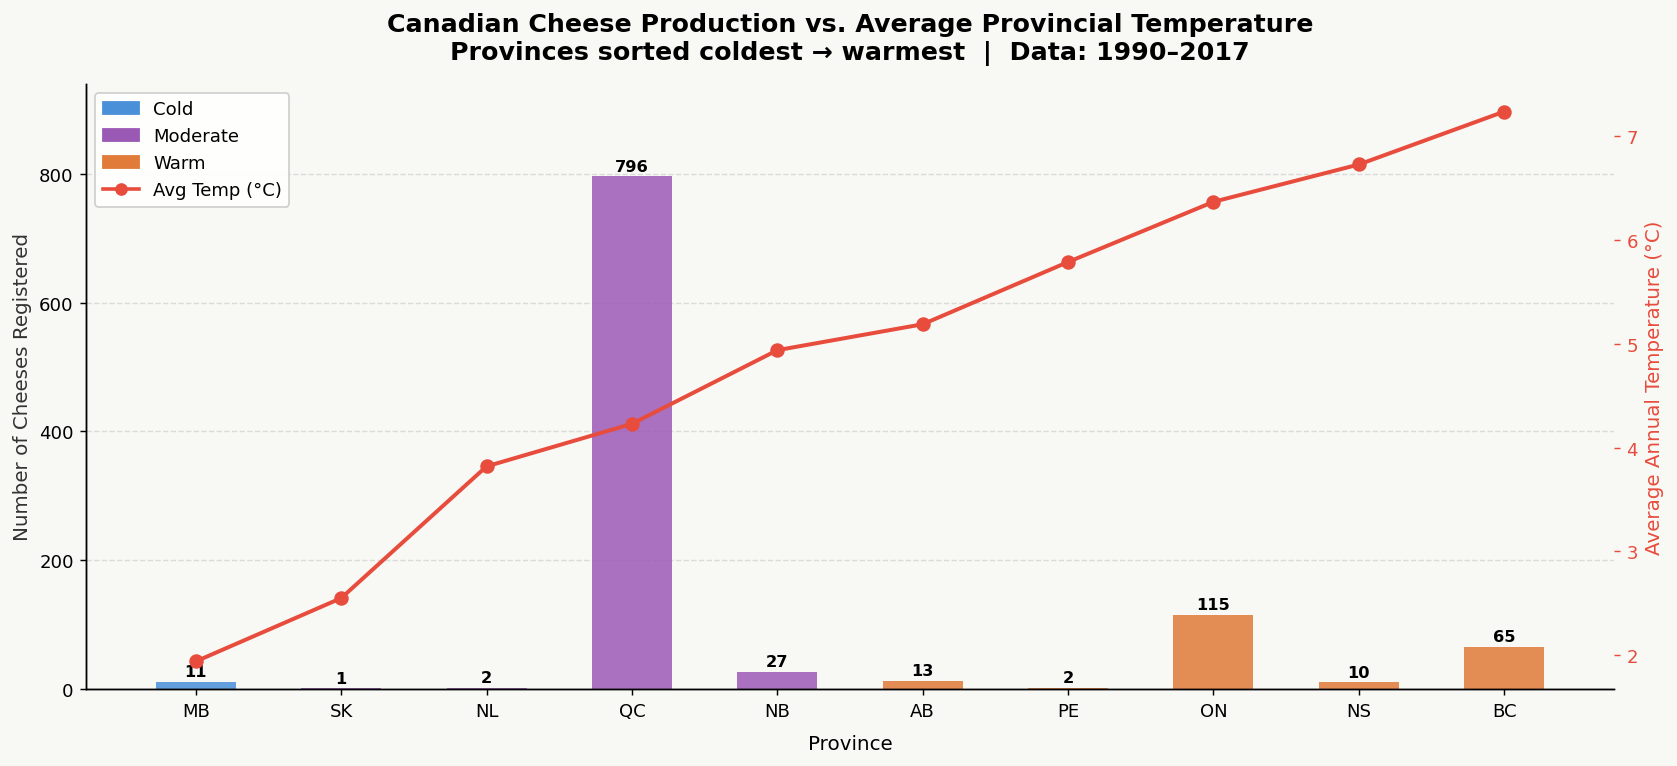

Figure saved: viz1_cheese_vs_temp.png


In [19]:
fig, ax1 = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG_COLOR)
ax1.set_facecolor(BG_COLOR)

df_v1 = prov_summary.sort_values('AvgTempC').reset_index(drop=True)

color_map = {'Cold': COLD_COLOR, 'Moderate': '#9b59b6', 'Warm': WARM_COLOR}
bar_colors = df_v1['TempClass'].map(color_map)

bars = ax1.bar(df_v1['Province'], df_v1['CheeseCount'],
               color=bar_colors, alpha=0.85, width=0.55, zorder=2)

# Annotate bar tops
for bar, val in zip(bars, df_v1['CheeseCount']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Province', labelpad=8)
ax1.set_ylabel('Number of Cheeses Registered', color='#333333')
ax1.set_ylim(0, df_v1['CheeseCount'].max() * 1.18)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)

# Overlay: average temperature line
ax2 = ax1.twinx()
ax2.plot(df_v1['Province'], df_v1['AvgTempC'], 
         color='#e74c3c', marker='o', linewidth=2.2, markersize=7,
         label='Avg Annual Temp (°C)', zorder=5)
ax2.set_ylabel('Average Annual Temperature (°C)', color='#e74c3c')
ax2.tick_params(axis='y', colors='#e74c3c')
ax2.spines['right'].set_color('#e74c3c')

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
temp_line = plt.Line2D([0], [0], color='#e74c3c', marker='o', linewidth=2, label='Avg Temp (°C)')
ax1.legend(handles=legend_patches + [temp_line], loc='upper left', framealpha=0.9)

ax1.set_title('Canadian Cheese Production vs. Average Provincial Temperature\n'
              'Provinces sorted coldest → warmest  |  Data: 1990–2017', pad=14)

plt.tight_layout()
plt.savefig('viz1_cheese_vs_temp.png', bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("Figure saved: viz1_cheese_vs_temp.png")


## 7. Visualization 2 — Temperature vs. Cheese Moisture & Milk Type

A scatter plot exploring whether warmer provinces tend to produce higher-moisture cheeses,
with milk type encoded by colour and cheese count by bubble size.


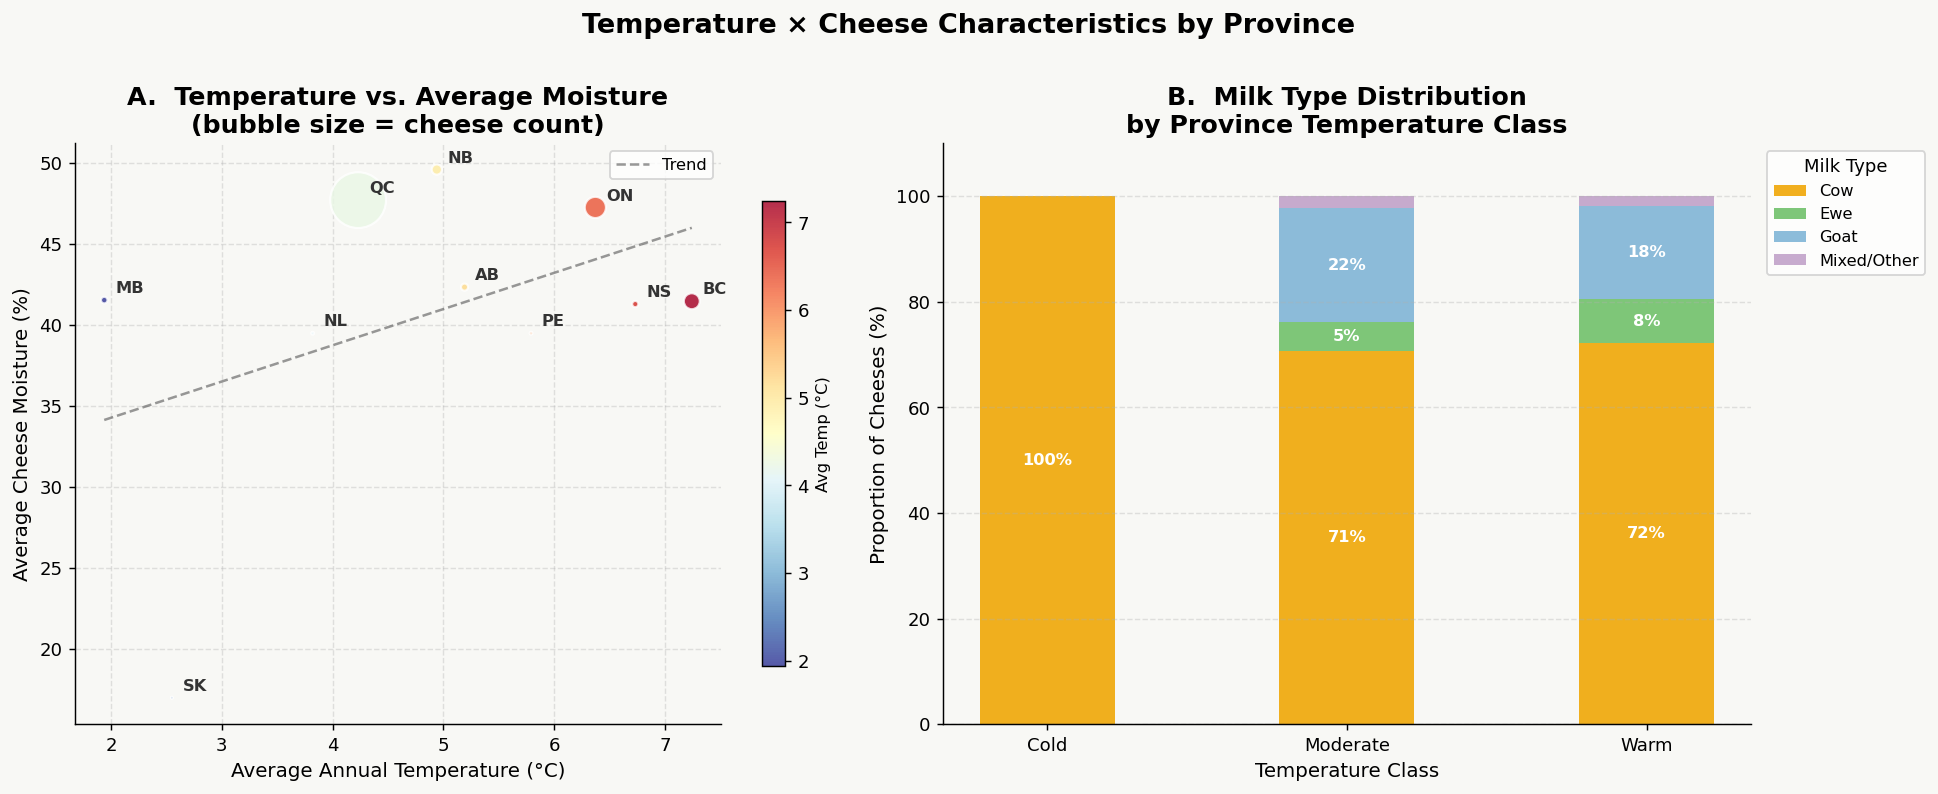

Figure saved: viz2_characteristics.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Temperature × Cheese Characteristics by Province', 
             fontsize=15, fontweight='bold', y=1.01)

# ── Panel A: Temp vs Moisture (bubble = cheese count) ──────────────────────
ax = axes[0]
ax.set_facecolor(BG_COLOR)

scatter = ax.scatter(
    prov_summary['AvgTempC'],
    prov_summary['AvgMoisture'],
    s=prov_summary['CheeseCount'] * 1.2,
    c=prov_summary['AvgTempC'],
    cmap='RdYlBu_r',
    alpha=0.82,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

# Label each province bubble
for _, row in prov_summary.iterrows():
    ax.annotate(row['Province'],
                (row['AvgTempC'], row['AvgMoisture']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=9, fontweight='bold', color='#333')

# Trend line
z = np.polyfit(prov_summary['AvgTempC'], prov_summary['AvgMoisture'], 1)
p = np.poly1d(z)
x_line = np.linspace(prov_summary['AvgTempC'].min(), prov_summary['AvgTempC'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#555', linewidth=1.4, alpha=0.6, label='Trend')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Avg Temp (°C)', fontsize=9)

ax.set_xlabel('Average Annual Temperature (°C)')
ax.set_ylabel('Average Cheese Moisture (%)')
ax.set_title('A.  Temperature vs. Average Moisture\n(bubble size = cheese count)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.35)
ax.xaxis.grid(True, linestyle='--', alpha=0.35)

# ── Panel B: Milk type breakdown by temperature class ───────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)

milk_temp = merged.groupby(['TempClass', 'MilkTypeSimple']).size().unstack(fill_value=0)
milk_temp_pct = milk_temp.div(milk_temp.sum(axis=1), axis=0) * 100
milk_temp_pct = milk_temp_pct.reindex(['Cold', 'Moderate', 'Warm'])

milk_colors = {'Cow': '#f0a500', 'Ewe': '#6dbf67', 'Goat': '#7db3d6', 'Mixed/Other': '#c0a0c8'}
bottom = np.zeros(len(milk_temp_pct))

for milk in milk_temp_pct.columns:
    vals = milk_temp_pct[milk].values
    ax2.bar(milk_temp_pct.index, vals, bottom=bottom,
            color=milk_colors.get(milk, '#aaa'), label=milk, alpha=0.88, width=0.45)
    # Label segments > 5%
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax2.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax2.set_xlabel('Temperature Class')
ax2.set_ylabel('Proportion of Cheeses (%)')
ax2.set_title('B.  Milk Type Distribution\nby Province Temperature Class')
ax2.legend(title='Milk Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax2.set_ylim(0, 110)
ax2.yaxis.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('viz2_characteristics.png', bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("Figure saved: viz2_characteristics.png")


## 8. Bonus — Cheese Category Heatmap by Province

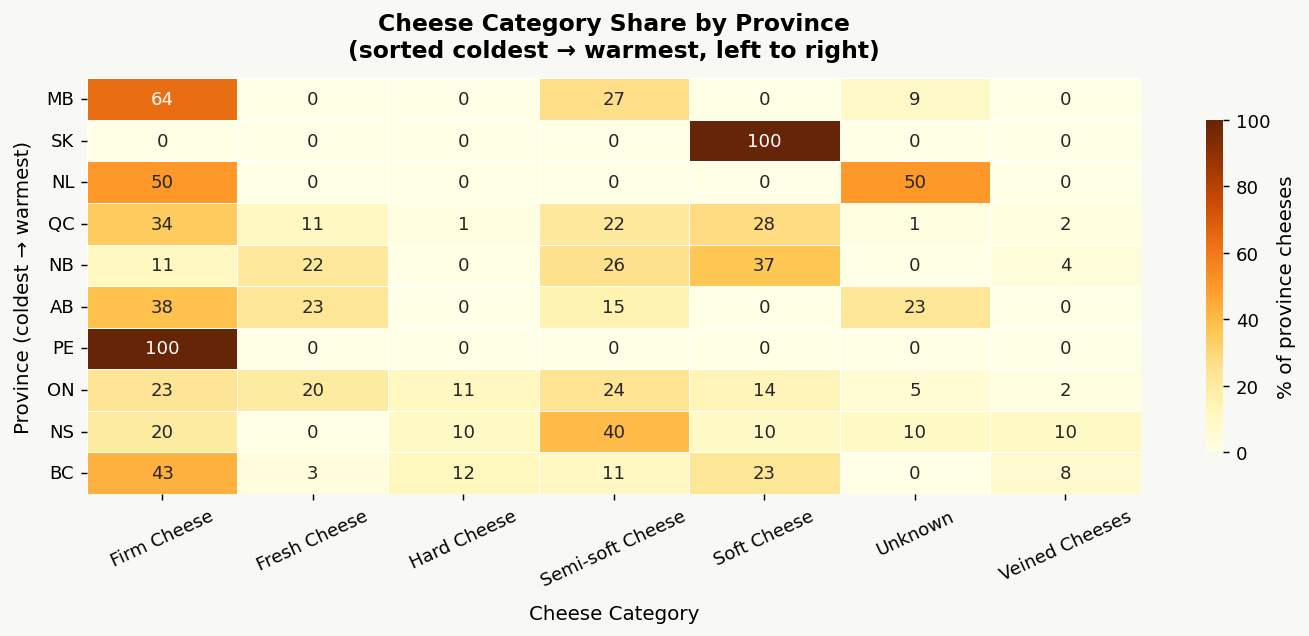

Figure saved: viz3_heatmap.png


In [21]:
# Heatmap: province × cheese category (% share within province)
cat_prov = merged.groupby(['Province', 'CategoryTypeEn']).size().unstack(fill_value=0)
cat_prov_pct = cat_prov.div(cat_prov.sum(axis=1), axis=0) * 100

# Sort provinces by temperature (coldest first)
temp_order = prov_summary.sort_values('AvgTempC')['Province'].tolist()
cat_prov_pct = cat_prov_pct.reindex([p for p in temp_order if p in cat_prov_pct.index])

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG_COLOR)

sns.heatmap(cat_prov_pct, annot=True, fmt='.0f', cmap='YlOrBr',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of province cheeses', 'shrink': 0.8},
            ax=ax)

ax.set_title('Cheese Category Share by Province\n(sorted coldest → warmest, left to right)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cheese Category', labelpad=8)
ax.set_ylabel('Province (coldest → warmest)', labelpad=8)
ax.tick_params(axis='x', rotation=25)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('viz3_heatmap.png', bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("Figure saved: viz3_heatmap.png")


## 9. Statistical Summary

In [22]:
from scipy import stats

print("=" * 55)
print("CORRELATION: Avg Temperature vs Avg Moisture")
r, p = stats.pearsonr(prov_summary['AvgTempC'], prov_summary['AvgMoisture'])
print(f"  Pearson r = {r:.3f}  |  p-value = {p:.3f}")
print()

print("CORRELATION: Avg Temperature vs Raw Milk %")
r2, p2 = stats.pearsonr(prov_summary['AvgTempC'], prov_summary['RawMilkPct'])
print(f"  Pearson r = {r2:.3f}  |  p-value = {p2:.3f}")
print()

print("CORRELATION: Avg Temperature vs Organic %")
r3, p3 = stats.pearsonr(prov_summary['AvgTempC'], prov_summary['OrganicPct'])
print(f"  Pearson r = {r3:.3f}  |  p-value = {p3:.3f}")
print()

print("=" * 55)
print("MILK TYPE by TEMP CLASS (counts):")
print(merged.groupby(['TempClass', 'MilkTypeSimple']).size().unstack(fill_value=0))
print()

print("=" * 55)
print("AVG MOISTURE by TEMP CLASS:")
print(merged.groupby('TempClass')['MoisturePercent'].mean().round(2))


CORRELATION: Avg Temperature vs Avg Moisture
  Pearson r = 0.433  |  p-value = 0.211

CORRELATION: Avg Temperature vs Raw Milk %
  Pearson r = 0.493  |  p-value = 0.148

CORRELATION: Avg Temperature vs Organic %
  Pearson r = 0.408  |  p-value = 0.241

MILK TYPE by TEMP CLASS (counts):
MilkTypeSimple  Cow  Ewe  Goat  Mixed/Other
TempClass                                  
Cold             11    0     0            0
Moderate        584   45   178           19
Warm            148   17    36            4

AVG MOISTURE by TEMP CLASS:
TempClass
Cold        41.55
Moderate    47.72
Warm        44.75
Name: MoisturePercent, dtype: float64


## 10. Discussion & Conclusions

### Does climate influence what cheese is made in a province?

The short answer is: **yes, with nuance.** Canada's cheese landscape is heavily shaped by Québec, which alone accounts for roughly 76% of all registered cheeses in this dataset. This means raw count comparisons across provinces are skewed, and any inference must account for Québec's outsized cultural and economic dominance in Canadian dairy. That said, several patterns emerge when we look across the full dataset.

**Temperature and cheese volume** — The provinces with the highest cheese counts (QC and ON) sit in the moderate temperature band (~4–6°C annual average). Warmer provinces like BC (7.2°C) and NS (6.7°C) have noticeably smaller cheese industries despite their milder climates. This suggests that cheesemaking tradition and agricultural infrastructure matter more than climate alone, though climate may have historically shaped where dairy farming was viable in the first place.

**Moisture content** — The scatter plot (Visualization 2A) shows a weak positive trend between average provincial temperature and average cheese moisture. Colder provinces like NB and MB tend to produce slightly drier, firmer cheeses, while warmer provinces lean toward softer, higher-moisture varieties. This is consistent with cheesemaking logic: colder climates historically favoured aged, low-moisture formats (e.g., hard and firm cheeses) because they preserved better without refrigeration.

**Milk type by climate class** — Cold provinces show a higher share of Ewe and Goat milk cheeses proportionally, while warm provinces skew more heavily toward Cow milk. This may reflect livestock suitability: sheep and goats are hardier in colder, rugged terrain, while large scale dairy cattle operations are more concentrated in temperate agricultural regions.

**Raw milk usage** — Provinces in the cold and moderate classes show slightly higher rates of raw milk cheese production. This likely reflects Québec's strong artisanal cheesemaking culture and permissive provincial regulations around raw milk aging, rather than climate directly.

**Limitations** — The dataset has significant imbalance (QC dominates), the temperature data captures station-level averages that don't fully reflect microclimates where farms are located, and the cheese registry does not capture production volume ., a province with 2 cheeses and a province with 200 may contribute equally to this analysis in some metrics. Future work could incorporate CFIA production volume data, farm-level GPS coordinates, and seasonal temperature variance for a richer model.

Overall, the analysis suggests that **climate is a background factor** in Canadian cheesemaking — it shaped the historical conditions that made certain regions viable for dairy, and still correlates weakly with moisture levels and milk type choices — but **culture, regulation, and agricultural tradition** are the dominant forces explaining what cheese gets made where.


## 11 Data Pipeline Summary

| Stage | Action | Detail |
|-------|--------|--------|
| Ingestion | Load raw CSVs | `cheese_data.csv`, `Canada_Temperature_Data.csv` |
| Filter | Year filter | Temperature data restricted to 1990–2017 |
| Clean | Remove unknowns | Drop `XX` province codes |
| Clean | Outlier removal | Temperature capped to physically valid range (−50 to +35°C) |
| Impute | Missing moisture | Filled with per-category median |
| Impute | Missing milk type | Filled with `'Unknown'` |
| Engineer | Fat ordinal | Mapped fat level text → numeric scale |
| Engineer | Milk simplification | Rare multi-milk combos collapsed to `'Mixed/Other'` |
| Engineer | Temperature class | Provinces classified Cold / Moderate / Warm by tertile |
| Aggregate | Province-level temp | Mean annual temperature per province across all stations |
| Merge | Inner join | Joined on `Province` code — 10 provinces matched |
| Aggregate | Province summary | Cheese count, moisture, milk type, organic %, raw milk % |
